Please upload your Titanic CSV file.


Saving Titanic-Dataset.csv to Titanic-Dataset (2).csv

Dataset loaded successfully!

1. INITIAL DATA INSPECTION

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.925

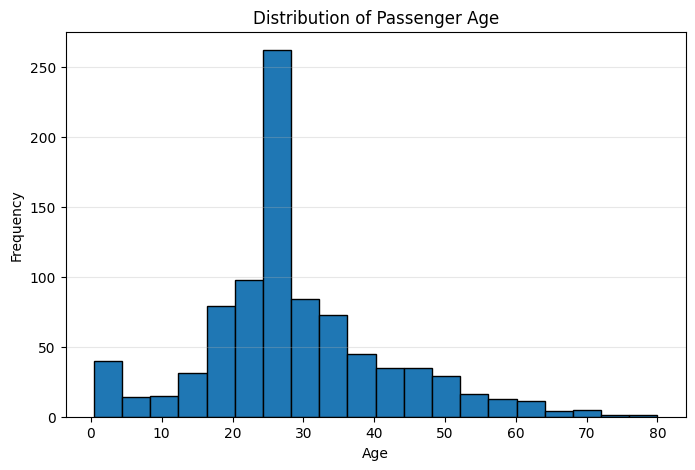

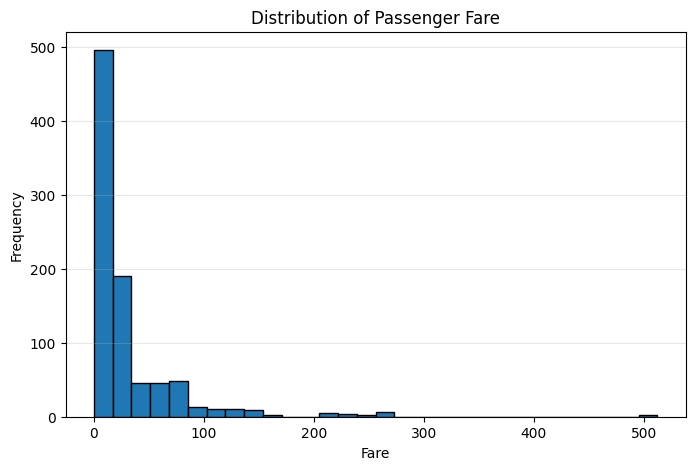

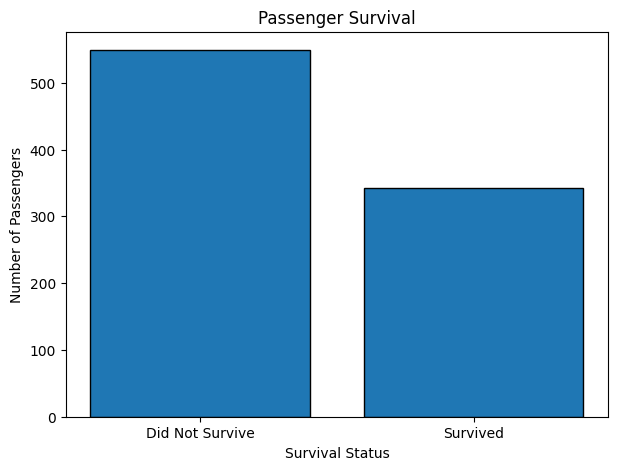

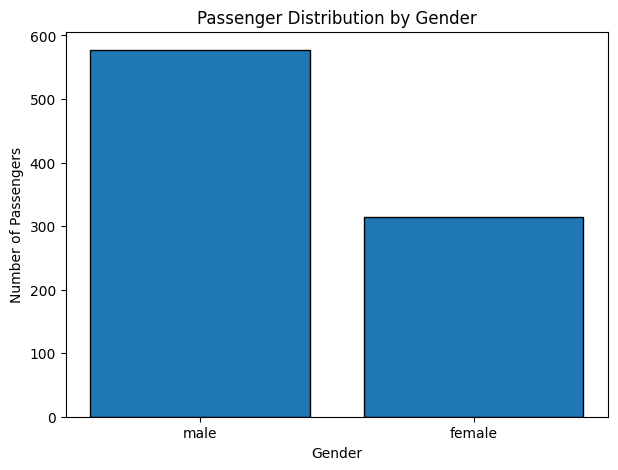


9. SURVIVAL BY GENDER
Survived    0    1
Sex               
female     81  233
male      468  109


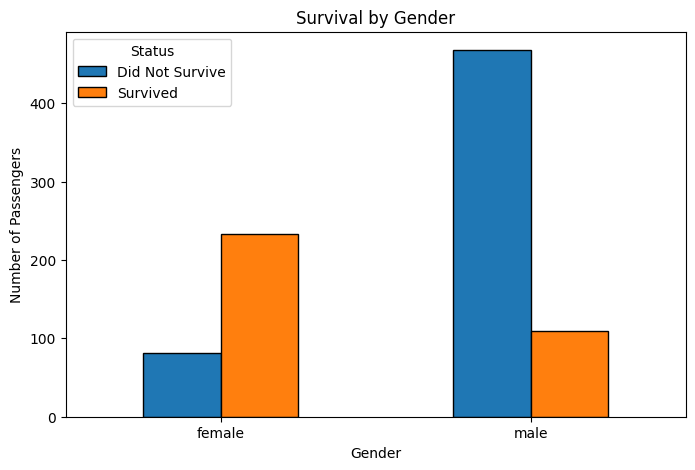


10. SURVIVAL BY PASSENGER CLASS
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


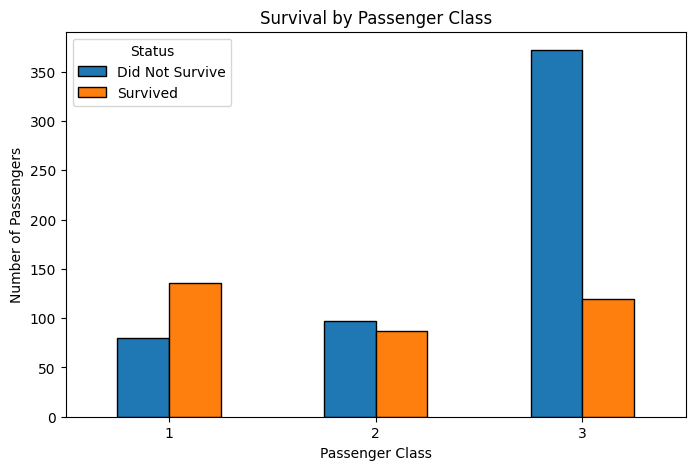


11. CORRELATION ANALYSIS

Correlation Matrix:
             PassengerId  Survived  Pclass   Age  SibSp  Parch  Fare
PassengerId         1.00     -0.01   -0.04  0.03  -0.06  -0.00  0.01
Survived           -0.01      1.00   -0.34 -0.06  -0.04   0.08  0.26
Pclass             -0.04     -0.34    1.00 -0.34   0.08   0.02 -0.55
Age                 0.03     -0.06   -0.34  1.00  -0.23  -0.17  0.10
SibSp              -0.06     -0.04    0.08 -0.23   1.00   0.41  0.16
Parch              -0.00      0.08    0.02 -0.17   0.41   1.00  0.22
Fare                0.01      0.26   -0.55  0.10   0.16   0.22  1.00


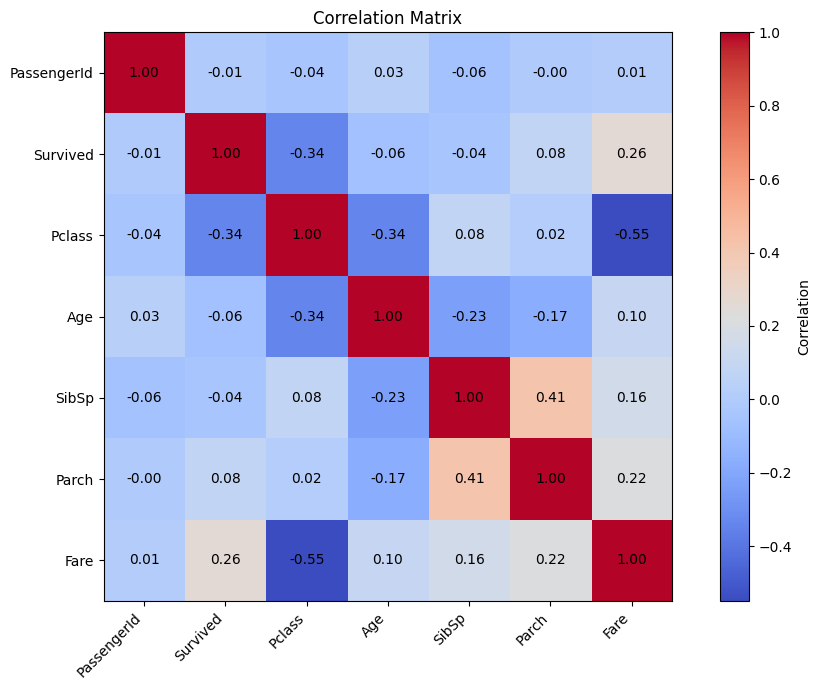

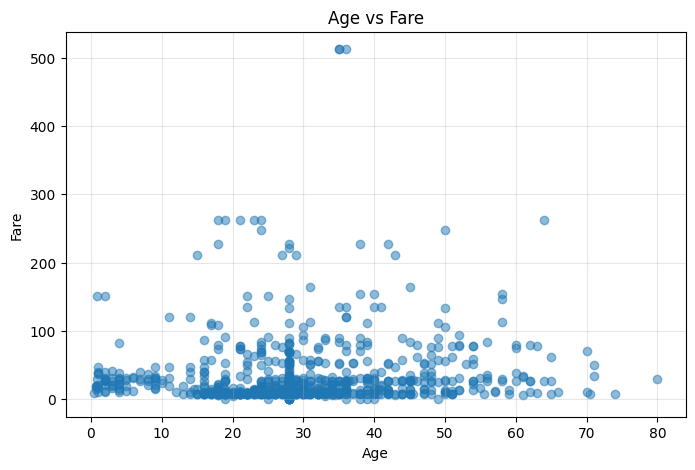

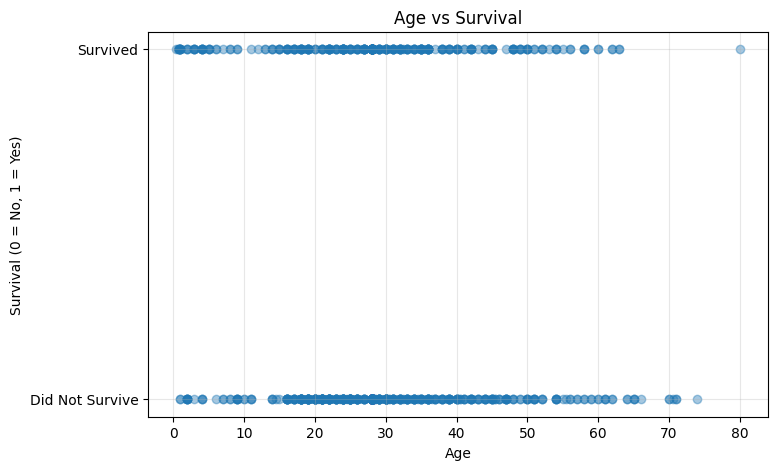


12. FINAL CLEANED DATASET

First 5 rows of cleaned dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  71.2833        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            3734

In [9]:
# =====================================================================
# DATA LOADING, CLEANING AND EXPLORATORY DATA ANALYSIS (EDA)
# Using NumPy, Pandas and Matplotlib
# Dataset: Titanic Dataset
# =====================================================================


# =====================================================================
# 1. IMPORT REQUIRED LIBRARIES
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =====================================================================
# 2. LOAD THE DATASET
# =====================================================================

# If you are using Google Colab, this will open a file-upload window.
# Upload your Titanic-Dataset.csv file.

try:
    from google.colab import files

    print("Please upload your Titanic CSV file.")
    uploaded = files.upload()

    # Get the uploaded filename automatically
    filename = next(iter(uploaded))

    # Read the CSV file
    df = pd.read_csv(filename)

except ImportError:
    # If you are using Jupyter Notebook / VS Code / local Python,
    # place Titanic-Dataset.csv in the same folder as your notebook.
    df = pd.read_csv("Titanic-Dataset.csv")


print("\nDataset loaded successfully!")


# =====================================================================
# 3. INITIAL DATA INSPECTION
# =====================================================================

print("\n" + "=" * 70)
print("1. INITIAL DATA INSPECTION")
print("=" * 70)

# Display first five rows
print("\nFirst 5 rows:")
print(df.head())

# Display last five rows
print("\nLast 5 rows:")
print(df.tail())

# Dataset dimensions
print("\nDataset shape:")
print(df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Data types
print("\nData types:")
print(df.dtypes)

# General information
print("\nDataset information:")
df.info()


# =====================================================================
# 4. CHECK FOR DUPLICATE ROWS
# =====================================================================

print("\n" + "=" * 70)
print("2. DUPLICATE VALUES")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)


# =====================================================================
# 5. CHECK FOR MISSING VALUES
# =====================================================================

print("\n" + "=" * 70)
print("3. MISSING VALUES")
print("=" * 70)

print("\nMissing values in each column:")
print(df.isnull().sum())

# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("\nPercentage of missing values:")
print(missing_percentage.round(2))


# =====================================================================
# 6. CREATE A COPY FOR DATA CLEANING
# =====================================================================

cleaned_df = df.copy()


# =====================================================================
# 7. HANDLE MISSING VALUES
# =====================================================================

print("\n" + "=" * 70)
print("4. DATA CLEANING")
print("=" * 70)

# ---------------------------------------------------------
# Handle missing Age values
# ---------------------------------------------------------

if "Age" in cleaned_df.columns:

    age_median = cleaned_df["Age"].median()

    cleaned_df["Age"] = cleaned_df["Age"].fillna(age_median)

    print("\nMissing Age values filled using median:")
    print("Median Age =", age_median)


# ---------------------------------------------------------
# Handle missing Embarked values
# ---------------------------------------------------------

if "Embarked" in cleaned_df.columns:

    embarked_mode = cleaned_df["Embarked"].mode()[0]

    cleaned_df["Embarked"] = cleaned_df["Embarked"].fillna(
        embarked_mode
    )

    print("\nMissing Embarked values filled using mode:")
    print("Mode =", embarked_mode)


# ---------------------------------------------------------
# Handle Cabin column
# ---------------------------------------------------------

if "Cabin" in cleaned_df.columns:

    # Cabin contains a large number of missing values,
    # so we remove it for this basic EDA experiment.
    cleaned_df = cleaned_df.drop(columns=["Cabin"])

    print("\nCabin column removed because it contains many missing values.")


# =====================================================================
# 8. CHECK MISSING VALUES AFTER CLEANING
# =====================================================================

print("\nMissing values after cleaning:")

print(cleaned_df.isnull().sum())


# =====================================================================
# 9. REMOVE DUPLICATE ROWS IF ANY
# =====================================================================

cleaned_df = cleaned_df.drop_duplicates()

print("\nShape after removing duplicates:")
print(cleaned_df.shape)


# =====================================================================
# 10. SUMMARY STATISTICS
# =====================================================================

print("\n" + "=" * 70)
print("5. SUMMARY STATISTICS")
print("=" * 70)

print("\nNumerical summary statistics:")

print(cleaned_df.describe())


# =====================================================================
# 11. CATEGORICAL SUMMARY
# =====================================================================

print("\nCategorical summary statistics:")

print(cleaned_df.describe(include="object"))


# =====================================================================
# 12. NUMPY STATISTICS
# =====================================================================

print("\n" + "=" * 70)
print("6. NUMPY STATISTICS")
print("=" * 70)

# Age statistics

age_values = cleaned_df["Age"].dropna().values

print("\nAge Statistics:")

print("Mean Age:",
      np.mean(age_values))

print("Median Age:",
      np.median(age_values))

print("Standard Deviation of Age:",
      np.std(age_values))

print("Minimum Age:",
      np.min(age_values))

print("Maximum Age:",
      np.max(age_values))


# Fare statistics

fare_values = cleaned_df["Fare"].dropna().values

print("\nFare Statistics:")

print("Mean Fare:",
      np.mean(fare_values))

print("Median Fare:",
      np.median(fare_values))

print("Standard Deviation of Fare:",
      np.std(fare_values))

print("Minimum Fare:",
      np.min(fare_values))

print("Maximum Fare:",
      np.max(fare_values))


# =====================================================================
# 13. FREQUENCY ANALYSIS
# =====================================================================

print("\n" + "=" * 70)
print("7. FREQUENCY ANALYSIS")
print("=" * 70)


# Gender distribution

print("\nGender Distribution:")

print(cleaned_df["Sex"].value_counts())


# Survival distribution

print("\nSurvival Distribution:")

print(cleaned_df["Survived"].value_counts())


# Passenger class distribution

print("\nPassenger Class Distribution:")

print(cleaned_df["Pclass"].value_counts())


# Port of embarkation

print("\nEmbarkation Distribution:")

print(cleaned_df["Embarked"].value_counts())


# =====================================================================
# 14. SURVIVAL PERCENTAGE
# =====================================================================

print("\n" + "=" * 70)
print("8. SURVIVAL PERCENTAGE")
print("=" * 70)

survival_percentage = (
    cleaned_df["Survived"]
    .value_counts(normalize=True)
    * 100
)

print("\nSurvival percentage:")

print(survival_percentage.round(2))


# =====================================================================
# 15. AGE DISTRIBUTION
# =====================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    cleaned_df["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()


# =====================================================================
# 16. FARE DISTRIBUTION
# =====================================================================

plt.figure(figsize=(8, 5))

plt.hist(
    cleaned_df["Fare"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()


# =====================================================================
# 17. SURVIVAL BAR CHART
# =====================================================================

survival_counts = cleaned_df["Survived"].value_counts().sort_index()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Did Not Survive", "Survived"],
    survival_counts.values,
    edgecolor="black"
)

plt.title("Passenger Survival")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

plt.show()


# =====================================================================
# 18. GENDER DISTRIBUTION
# =====================================================================

gender_counts = cleaned_df["Sex"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    gender_counts.index,
    gender_counts.values,
    edgecolor="black"
)

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()


# =====================================================================
# 19. SURVIVAL BY GENDER
# =====================================================================

survival_by_sex = pd.crosstab(
    cleaned_df["Sex"],
    cleaned_df["Survived"]
)

print("\n" + "=" * 70)
print("9. SURVIVAL BY GENDER")
print("=" * 70)

print(survival_by_sex)


survival_by_sex.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.xticks(rotation=0)

plt.legend(
    ["Did Not Survive", "Survived"],
    title="Status"
)

plt.show()


# =====================================================================
# 20. SURVIVAL BY PASSENGER CLASS
# =====================================================================

survival_by_class = pd.crosstab(
    cleaned_df["Pclass"],
    cleaned_df["Survived"]
)

print("\n" + "=" * 70)
print("10. SURVIVAL BY PASSENGER CLASS")
print("=" * 70)

print(survival_by_class)


survival_by_class.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.xticks(rotation=0)

plt.legend(
    ["Did Not Survive", "Survived"],
    title="Status"
)

plt.show()


# =====================================================================
# 21. CORRELATION MATRIX
# =====================================================================

print("\n" + "=" * 70)
print("11. CORRELATION ANALYSIS")
print("=" * 70)

# Select only numerical columns

numeric_df = cleaned_df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")

print(correlation_matrix.round(2))


# =====================================================================
# 22. CORRELATION HEATMAP USING MATPLOTLIB
# =====================================================================

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    interpolation="nearest"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

# Add correlation values to the plot

for i in range(len(correlation_matrix.columns)):

    for j in range(len(correlation_matrix.columns)):

        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()


# =====================================================================
# 23. SCATTER PLOT - AGE VS FARE
# =====================================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    cleaned_df["Age"],
    cleaned_df["Fare"],
    alpha=0.5
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.grid(alpha=0.3)

plt.show()


# =====================================================================
# 24. SCATTER PLOT - AGE VS SURVIVAL
# =====================================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    cleaned_df["Age"],
    cleaned_df["Survived"],
    alpha=0.4
)

plt.title("Age vs Survival")
plt.xlabel("Age")
plt.ylabel("Survival (0 = No, 1 = Yes)")

plt.yticks(
    [0, 1],
    ["Did Not Survive", "Survived"]
)

plt.grid(alpha=0.3)

plt.show()


# =====================================================================
# 25. FINAL DATASET INSPECTION
# =====================================================================

print("\n" + "=" * 70)
print("12. FINAL CLEANED DATASET")
print("=" * 70)

print("\nFirst 5 rows of cleaned dataset:")

print(cleaned_df.head())


print("\nFinal dataset shape:")

print(cleaned_df.shape)


print("\nFinal missing-value count:")

print(cleaned_df.isnull().sum())


# =====================================================================
# 26. FINAL CONCLUSION
# =====================================================================

print("\n" + "=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)

